In [ ]:
# Monte-Carlo post-processing - mcvis.ipynb
import pandas as pd, numpy as np, seaborn as sns, matplotlib.pyplot as plt
sns.set_theme(style="whitegrid")

FILE_NO = "_new_5_metere_standoff2"

# 1) Scalars (CSV) -> df   [leave this as-is]
CSV_PATH = f"mc_data/mc_output{FILE_NO}.csv"
df = pd.read_csv(CSV_PATH)
print(f"Loaded {len(df):,} rows from {CSV_PATH}")

# 2) Per-scene grids (Parquet) -> grid_df
PARQUET = f"mc_data/grids_mc{FILE_NO}.parquet"
grid_df = pd.read_parquet(PARQUET)
print(f"Loaded {len(grid_df):,} rows from {PARQUET}")

# Optional sanity check: they should be the same length and aligned by row
assert len(df) == len(grid_df), "CSV and Parquet row counts differ; plotting may misalign."


Loaded 10,000 rows from mc_data/mc_output1.csv
Loaded 10,000 rows from mc_data/grids_mc1.parquet


## ========== **Visualize the shield geometry** ==========

### Flat Shield

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from geometry import Shield              

#  FLAT (disk) shield
def flat_vertices(radius: float,
                  n_facets: int = 40,
                  flip_z: bool = False):
    """
    verts, faces = flat_vertices(radius, n_facets)

    • radius     disk radius (m)
    • n_facets   how many straight edges to approximate the circle
    • flip_z     True -> plate lies at Z = -theta   (convex faces +Z),
                  False (default) leaves it at Z = theta
    """
    phi = np.linspace(0, 2*np.pi, n_facets, endpoint=False)
    rim = np.c_[radius*np.cos(phi), radius*np.sin(phi), np.zeros(n_facets)]
    center = np.array([[0.0, 0.0, 0.0]])
    verts = np.vstack([center, rim])                # theta = centre
    faces = [[0, i+1, ((i+1)%n_facets)+1] for i in range(n_facets)]

    if flip_z:
        verts[:, 2] -= 1e-12   # tiny negative value so it’s “below” origin

    return verts, faces


def plot_flat(shield: Shield, flip_z: bool = False):
    V, F = flat_vertices(shield.primary_dim, flip_z=flip_z)
    fig = plt.figure(figsize=(6, 6)); ax = fig.add_subplot(111, projection='3d')
    for f in F:
        loop = f + [f[0]]; ax.plot(*(V[loop].T))
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.set_title(f'Flat disk – r = {shield.primary_dim:.2f} m')
    plt.tight_layout(); plt.show()
    
def plot_shield(shield: Shield, flip_z: bool = True):
    fig = plt.figure(figsize=(6, 6))
    ax  = fig.add_subplot(111, projection='3d')

    if shield.profile == "cupola":
        V, F = cupola_vertices(shield.primary_dim,
                               include_base=shield.include_base,
                               include_top =shield.include_top,
                               flip_z=flip_z)
    else:
        raise ValueError("Only profile='cupola' is implemented here.")

    for f in F:
        loop = f + [f[0]]
        ax.plot(*(V[loop].T), linewidth=1)

    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.set_title(f'{shield.profile.capitalize()} – edge = {shield.primary_dim:.2f} m')
    plt.tight_layout()
    plt.show()



### Pyramid Shield

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from geometry import Shield

#  PYRAMID shield  
def pyramid_vertices(a: float,
                     include_base: bool = True,
                     flip_z: bool       = False):
    """
    verts, faces = pyramid_vertices(a, ...)

    • a              edge length (metres)
    • include_base   add the square base (absorbing in MC, but nice for plots)
    • flip_z         True -> base down (convex faces +Z); default base up
    """
    h = a / np.sqrt(2)                          # height for equilateral faces
    # base square (CCW if viewed from +Z)
    Vb = np.array([[+a/2, +a/2, 0.0],
                   [-a/2, +a/2, 0.0],
                   [-a/2, -a/2, 0.0],
                   [+a/2, -a/2, 0.0]])
    Vtop = np.array([[0.0, 0.0, h]])
    verts = np.vstack([Vtop, Vb])               # theta = apex

    faces = [[0, i+1, (i+1)%4 +1] for i in range(4)]   # 4 triangles
    if include_base:
        faces.append([1,2,3,4])                 # square base

    if flip_z:
        verts[:, 2] *= -1

    return verts, faces


def plot_pyramid(shield: Shield, flip_z: bool = True):
    V, F = pyramid_vertices(shield.primary_dim, flip_z=flip_z)
    fig = plt.figure(figsize=(6, 6)); ax = fig.add_subplot(111, projection='3d')
    for f in F:
        loop = f + [f[0]]; ax.plot(*(V[loop].T))
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.set_title(f'Square pyramid - a = {shield.primary_dim:.2f} m')
    plt.tight_layout(); plt.show()
    
def cupola_vertices(a: float,
                    include_base: bool = True,
                    include_top:  bool = False,
                    flip_z: bool       = False):
    """
    verts, faces = cupola_vertices(a, ...)

    • a            edge length (metres)
    • include_base add the decagon fan
    • include_top  add the tiny pentagon roof
    • flip_z       True  -> base faces -Z  (diagram view)
    """
    # Key radii / heights 
    r_p = a / (2*np.sin(np.pi/5))          # pentagon circ. radius
    r_d = a / (2*np.sin(np.pi/10))         # decagon circ. radius
    z_p, z_d = 0.0, -a                     # squares are one edge tall

    # Vertex rings
    phi_p = np.linspace(np.pi/2, 2*np.pi + np.pi/2, 5, endpoint=False)
    Vp = np.c_[r_p*np.cos(phi_p),  r_p*np.sin(phi_p),  np.full(5, z_p)]

    # two decagon verts per square: –18 degrres & +18 degrees around each pentagon vert
    phi_d = phi_p[:, None] + np.deg2rad([-18, +18])
    Vd = np.c_[r_d*np.cos(phi_d.ravel()),
              r_d*np.sin(phi_d.ravel()),
              np.full(10, z_d)]

    verts = np.vstack([Vp, Vd])            # 15 vertices total

    # Faces 
    squares   = [[i,
                  (i+1) % 5,
                  5+(2*i+1) % 10,
                  5+2*i]                   # bottom uses decagon verts
                 for i in range(5)]

    triangles = [[i,
                  5+2*i,
                  5+(2*i+1) % 10]            # triangle between squares
                 for i in range(5)]

    faces = squares + triangles

    if include_base:                       # 5-triangle decagon fan
        faces += [[5+i,
                   5+(i+1) % 10,
                   5+(i+2)%10]
                  for i in range(0,10,2)]
    if include_top:                        # tiny roof (optional)
        faces += [[0,1,2], [0,2,3], [0,3,4]]

    if flip_z:
        verts[:, 2] *= -1

    return verts, faces


### Spherical Cap Shield

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from geometry import Shield

def cap_vertices(a: float,
                 curvature: float,
                 n_theta: int = 15,
                 n_phi: int   = 32,
                 flip_z: bool = False):
    """
    verts, faces = cap_vertices(edge_radius, curvature, ...)

    • a          rim radius (m)   ( = shield.primary_dim in your code)
    • curvature  1 / sphere_radius  (1/m)
    • n_theta    # of latitude bands
    • n_phi      # of longitude splits
    • flip_z     True -> bowl faces +Z (convex up); default convex down
    """
    R = 1.0 / curvature
    theta_max = np.arcsin(a / R)               # half-angle of cap
    theta = np.linspace(0, theta_max, n_theta) # theta = pole, max = rim
    phi = np.linspace(0, 2*np.pi, n_phi, endpoint=False)

    verts = []
    for t in theta:
        ring_r = R * np.sin(t)
        z      = R * (np.cos(t) - np.cos(theta_max))    # z = theta at rim
        verts.extend(np.c_[ring_r*np.cos(phi), ring_r*np.sin(phi), np.full(n_phi, z)])
    verts = np.array(verts)

    # build quad strips (as triangle pairs)
    n_rings = len(theta)
    faces = []
    for r in range(n_rings-1):
        for p in range(n_phi):
            p_next = (p+1) % n_phi
            v00 = r*n_phi + p
            v01 = r*n_phi + p_next
            v10 = (r+1)*n_phi + p
            v11 = (r+1)*n_phi + p_next
            faces += [[v00, v10, v11], [v00, v11, v01]]

    if flip_z:
        verts[:, 2] *= -1

    return verts, faces


def plot_cap(shield: Shield, flip_z: bool = False):
    V, F = cap_vertices(shield.primary_dim,
                        curvature=shield.shape_param,
                        flip_z=flip_z)
    fig = plt.figure(figsize=(6, 6)); ax = fig.add_subplot(111, projection='3d')
    for f in F:
        loop = f + [f[0]]; ax.plot(*(V[loop].T))
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.set_title(f'Spherical cap – r = {shield.primary_dim:.2f} m')
    plt.tight_layout(); plt.show()


 flat


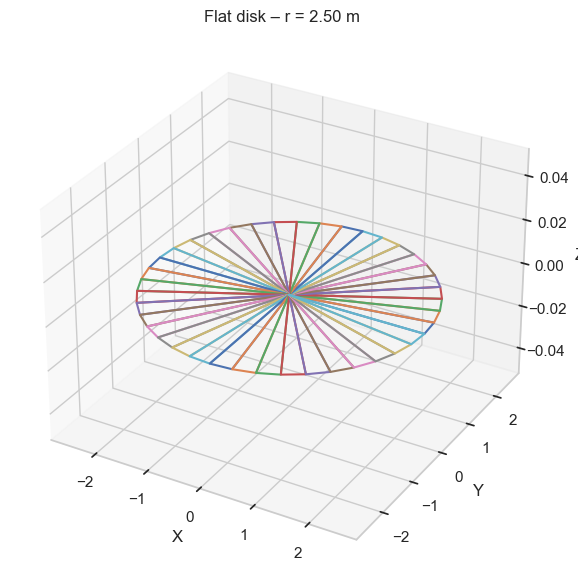

 pyramid


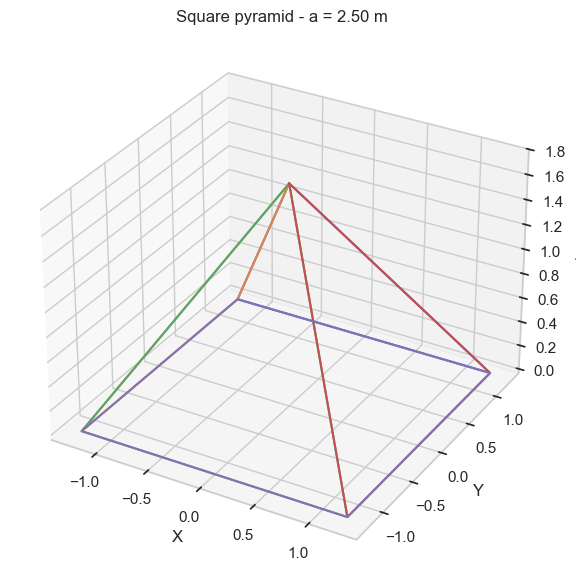

 cap


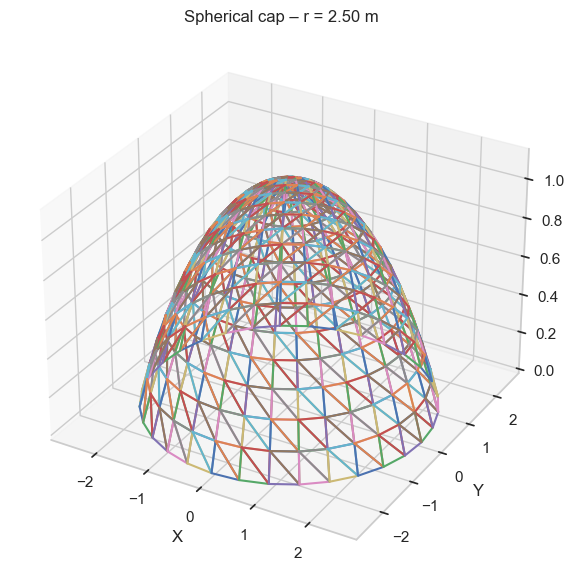

 cupola


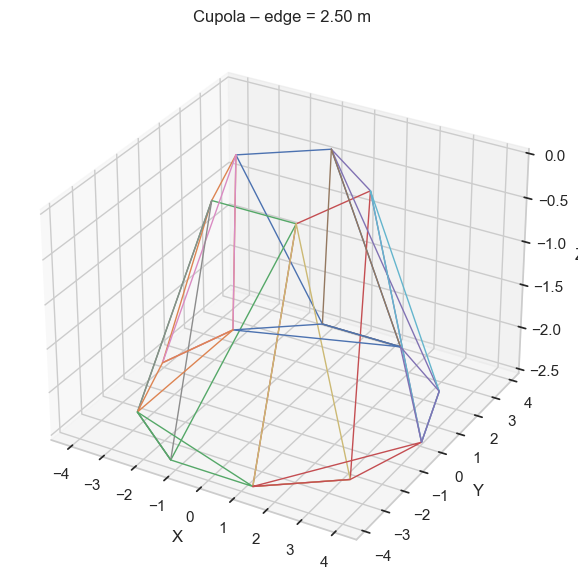

In [ ]:
# make one shield per shape so each helper sees the profile it expects
demo_shields = {
    "flat":   Shield(primary_dim=2.5, shape_param=0.0,  thickness=0.003,
                     coating_type="specular", profile="flat"),
    "pyramid":Shield(primary_dim=2.5, shape_param=0.0,  thickness=0.003,
                     coating_type="specular", profile="pyramid"),
    "cap":    Shield(primary_dim=2.5, shape_param=0.3,  thickness=0.003,
                     coating_type="specular", profile="cap"),   # R is about 3.33 m
    "cupola": Shield(primary_dim=2.5, shape_param=1.0,  thickness=0.003,
                     coating_type="specular", profile="cupola"),
}

profiles = {
    "flat":   plot_flat,
    "pyramid":plot_pyramid,
    "cap":    plot_cap,
    "cupola": plot_shield,
}

for name, plotter in profiles.items():
    print(f" {name}")
    plotter(demo_shields[name], flip_z=False)


,primary_dim,shape_param,mass,mean_deflection_deg,hit_ratio,wake_intrusion_ratio,wafer_flux_m2s
count,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,1.000000e+04
mean,3.5044,1.0605,529.2696,65.1595,0.0004,0.3657,1.056107e+18
std,1.4479,0.8323,734.0832,27.5727,0.0009,0.2304,2.051666e+18
min,1.0002,0.0000,2.8627,12.5529,0.0000,0.0550,0.000000e+00
5%,1.2565,0.0000,5.2011,12.8313,0.0000,0.1070,0.000000e+00
25%,2.2447,0.5058,20.0445,52.7460,0.0000,0.1237,0.000000e+00
50%,3.5292,1.0000,249.0219,61.4544,0.0000,0.3077,0.000000e+00
75%,4.7530,1.4954,679.5308,89.5522,0.0000,0.4372,0.000000e+00
95%,5.7539,2.6781,2263.6052,101.6210,0.0025,0.8469,5.649430e+18
max,5.9998,3.0000,4277.2060,126.5621,0.0057,0.9429,1.201210e+19



========= Hit ratio statistics by shield profile =========

          count          mean       std  min     25%    50%     75%     max
profile                                                                    
cap      2493.0  0.000000e+00  0.000000  0.0  0.0000  0.000  0.0000  0.0000
cupola   2556.0  1.443975e-03  0.001168  0.0  0.0006  0.001  0.0021  0.0057
flat     2485.0  0.000000e+00  0.000000  0.0  0.0000  0.000  0.0000  0.0000
pyramid  2466.0  4.055150e-07  0.000006  0.0  0.0000  0.000  0.0000  0.0001


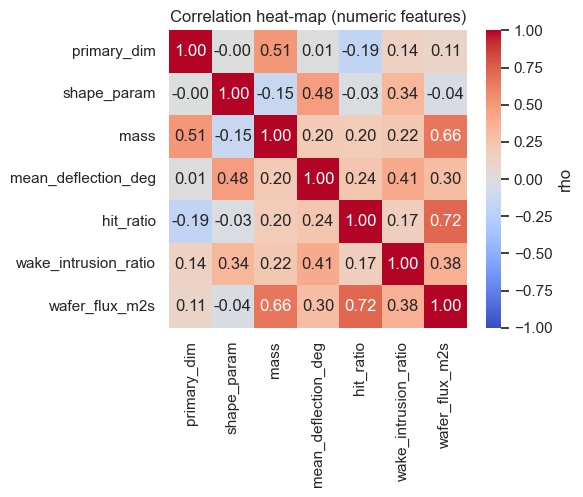

In [ ]:
# --- Descriptive statistics & correlation heat‑map --------------------------
numeric_cols = ["primary_dim", "shape_param", "mass",
                "mean_deflection_deg", "hit_ratio", "wake_intrusion_ratio", "wafer_flux_m2s"]

display(df[numeric_cols].describe(percentiles=[.05,.25,.5,.75,.95]).round(4))
print(f"\n========= Hit ratio statistics by shield profile =========\n")
print(df.groupby("profile")["hit_ratio"].describe())

corr = df[numeric_cols].corr(method="pearson")

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, fmt=".2f", vmin=-1, vmax=1, cmap="coolwarm",
            square=True, cbar_kws={"label":"rho"})
plt.title("Correlation heat-map (numeric features)")
plt.tight_layout()
plt.show()


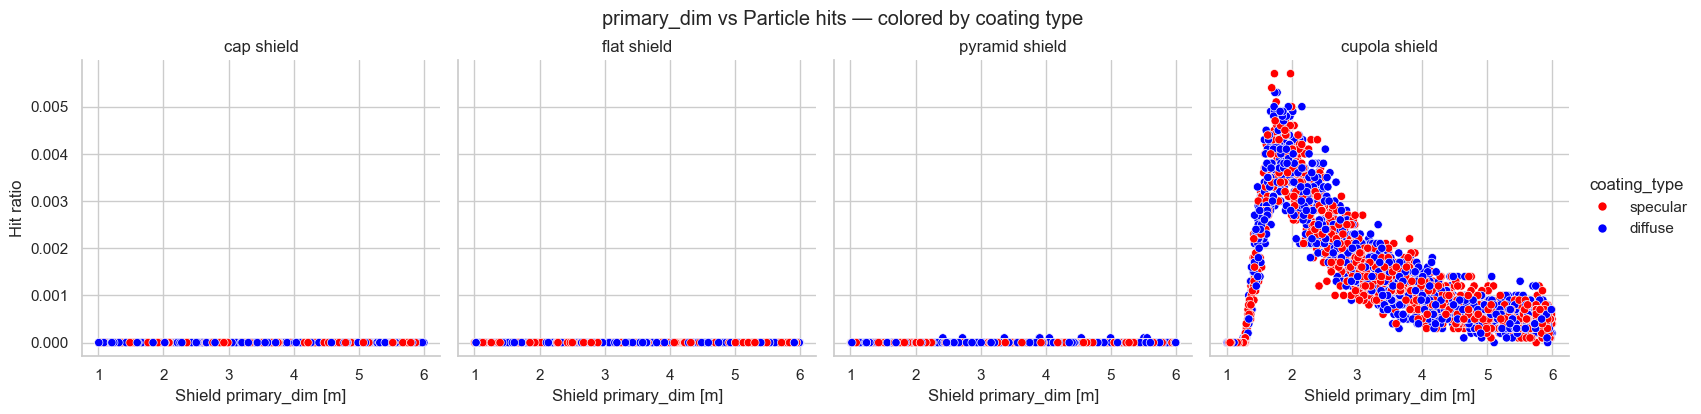

In [ ]:
# --- Scatterplots: hit_ratio -----------------------------------------------
custom_palette = {
    "diffuse": "blue",
    "specular": "red"
}

g = sns.relplot(
    data=df, x="primary_dim", y="hit_ratio",
    col="profile", hue="coating_type", palette=custom_palette,
    col_order=["cap", "flat", "pyramid", "cupola"],
    height=4, aspect=1
)

g.set_axis_labels("Shield primary_dim [m]", "Hit ratio")
g.set_titles(col_template="{col_name} shield")
g.fig.suptitle("primary_dim vs Particle hits — colored by coating type", y=1.03)
plt.show()


Detected grid: 50 x 50
cap     | scenes=2493 | total wafer hits=0
flat    | scenes=2485 | total wafer hits=0
pyramid | scenes=2466 | total wafer hits=10
cupola  | scenes=2556 | total wafer hits=36908


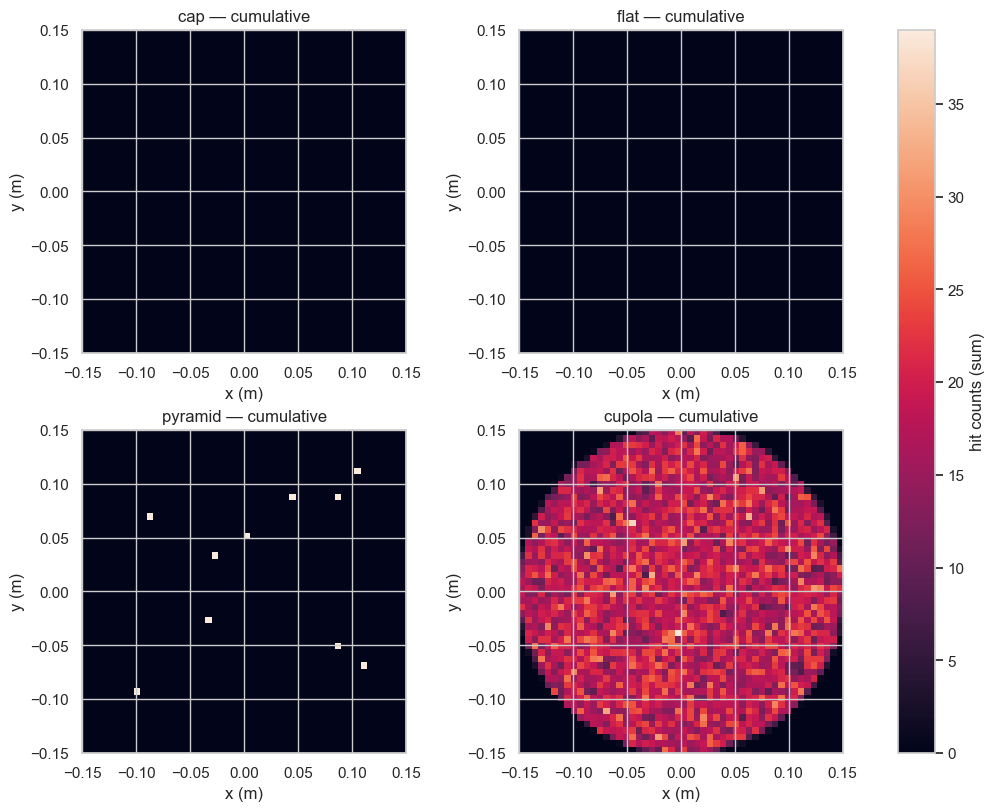

In [ ]:
# --- Heatmap of cummulative hits:
# Discover grid columns and size from grid_df
grid_cols = sorted([c for c in grid_df.columns if c.startswith("g")])
N = int(np.sqrt(len(grid_cols)))
print(f"Detected grid: {N} x {N}")

def plot_heatmap(G, R=0.15, title=""):
    plt.figure(figsize=(5,4))
    plt.imshow(G, origin="lower", extent=[-R, R, -R, R], vmin=0)
    plt.xlabel("x (m)"); plt.ylabel("y (m)")
    plt.title(title); plt.colorbar(label="hit counts")
    plt.tight_layout(); plt.show()

# --- cumulative wafer-hit heatmaps for each profile (sum over scenes) ---
# Totals per profile
profiles = ["cap","flat","pyramid","cupola"]
for p in profiles:
    sub = grid_df.loc[grid_df["profile"]==p, grid_cols]
    total = sub.to_numpy(dtype=np.float64).sum()
    print(f"{p:7s} | scenes={len(sub):4d} | total wafer hits={int(total)}")

# Optional: plot with per-panel scaling (or log scale) to reveal tiny counts
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

fig, axes = plt.subplots(2,2,figsize=(10,8), constrained_layout=True)
R = 0.15
for ax, p in zip(axes.flat, profiles):
    sub = grid_df.loc[grid_df["profile"]==p, grid_cols]
    G = sub.to_numpy(dtype=np.float64).sum(0).reshape(N,N)
    if G.max() > 0:
        # choose ONE of these:
        im = ax.imshow(G, origin="lower", extent=[-R,R,-R,R], vmin=0, vmax=G.max())  # per-panel linear
        # im = ax.imshow(G, origin="lower", extent=[-R,R,-R,R], norm=LogNorm(vmin=1, vmax=G.max()))  # log scale
    else:
        im = ax.imshow(G, origin="lower", extent=[-R,R,-R,R], vmin=0, vmax=1)
    ax.set_title(f"{p} — cumulative")
    ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)")
fig.colorbar(im, ax=axes.ravel().tolist(), label="hit counts (sum)")
plt.show()

C:\Users\Risha\AppData\Local\Temp\ipykernel_30756\1968032648.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  pyramid_df = df[df['profile'] == 'pyramid'][df['coating_type'] == 'specular']


,primary_dim,shape_param,mass,mean_deflection_deg,hit_ratio,wake_intrusion_ratio,wafer_flux_m2s
count,1233.0000,1233.0000,1233.0000,1233.0000,1233.0,1233.0000,1233.0
mean,3.4987,1.0016,501.9801,91.7889,0.0,0.1128,0.0
std,1.4573,0.2821,390.3689,16.7311,0.0,0.0064,0.0
min,1.0093,0.5003,24.7612,66.8602,0.0,0.0974,0.0
5%,1.2650,0.5564,50.2930,69.0155,0.0,0.1044,0.0
25%,2.1888,0.7607,161.6200,77.2324,0.0,0.1084,0.0
50%,3.5325,0.9993,424.9104,89.7168,0.0,0.1119,0.0
75%,4.7564,1.2410,762.2612,105.1468,0.0,0.1161,0.0
95%,5.7616,1.4391,1261.3965,121.6617,0.0,0.1260,0.0
max,5.9979,1.5000,1924.3358,126.5621,0.0,0.1382,0.0



========= Hit ratio statistics by shield profile =========

          count          mean       std  min     25%    50%     75%     max
profile                                                                    
cap      2493.0  0.000000e+00  0.000000  0.0  0.0000  0.000  0.0000  0.0000
cupola   2556.0  1.443975e-03  0.001168  0.0  0.0006  0.001  0.0021  0.0057
flat     2485.0  0.000000e+00  0.000000  0.0  0.0000  0.000  0.0000  0.0000
pyramid  2466.0  4.055150e-07  0.000006  0.0  0.0000  0.000  0.0000  0.0001


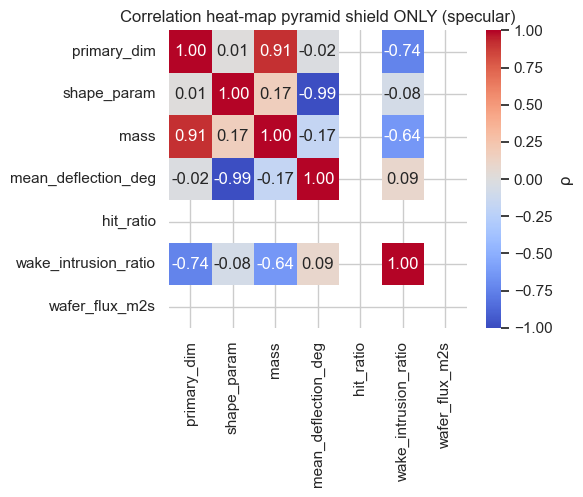

In [ ]:
# Correlation matrix for only the pyramid

pyramid_df = df[df['profile'] == 'pyramid'][df['coating_type'] == 'specular']
numeric_cols = ["primary_dim", "shape_param", "mass",
                "mean_deflection_deg", "hit_ratio", "wake_intrusion_ratio", "wafer_flux_m2s"]


display(pyramid_df[numeric_cols].describe(percentiles=[.05,.25,.5,.75,.95]).round(4))
print(f"\n========= Hit ratio statistics by shield profile =========\n")
print(df.groupby("profile")["hit_ratio"].describe())


corr = pyramid_df[numeric_cols].corr(method="pearson")

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, fmt=".2f", vmin=-1, vmax=1, cmap="coolwarm",
            square=True, cbar_kws={"label":"ρ"})
plt.title("Correlation heat-map pyramid shield ONLY (specular)")
plt.tight_layout()
plt.show()


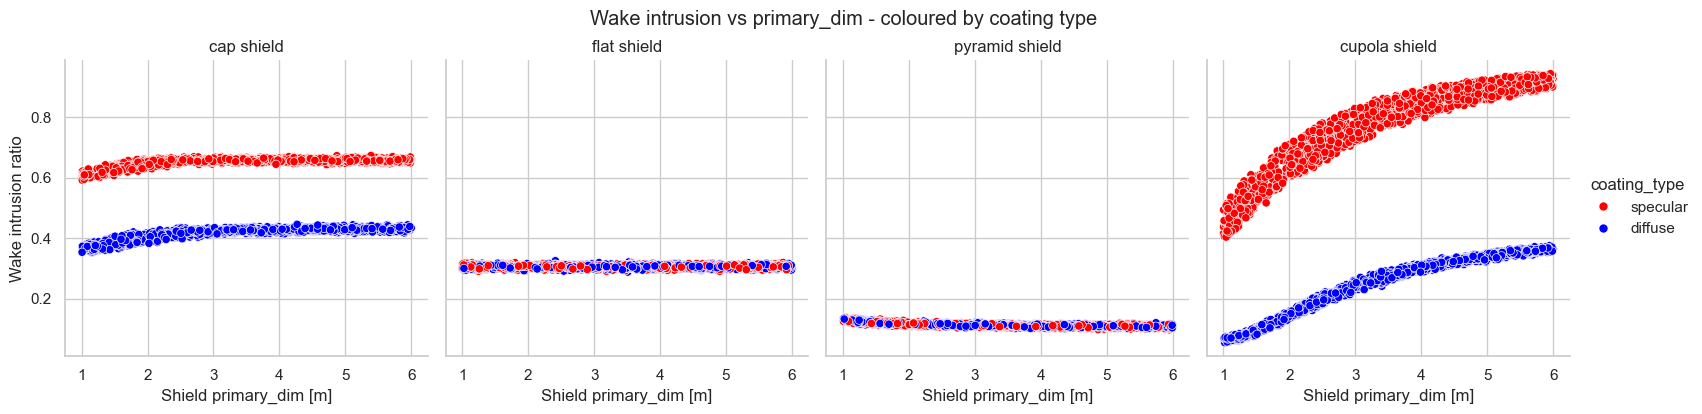

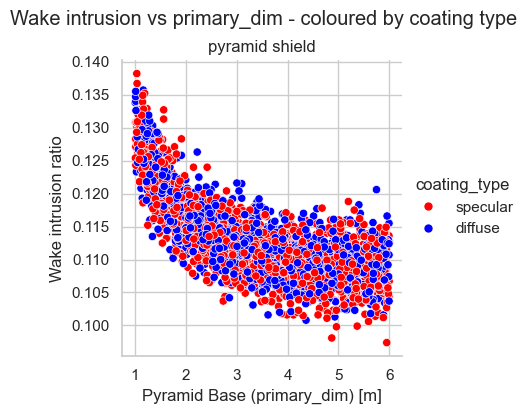

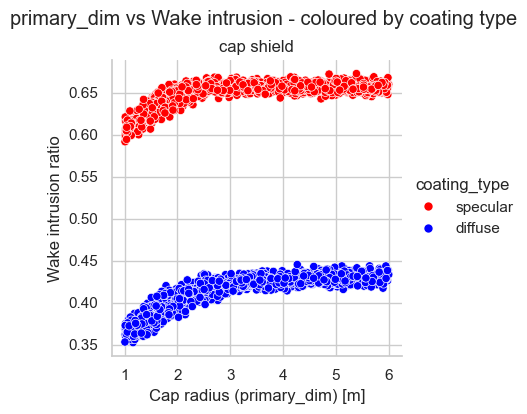

In [ ]:
# --- Scatterplots: wake_intrusion_ratio -------------------------------------
custom_palette = {
    "specular": "red", 
    "diffuse": "blue",   
}

# Plot with flipped colors
g = sns.relplot(
    data=df, x="primary_dim", y="wake_intrusion_ratio",
    col="profile", hue="coating_type", palette=custom_palette,
    col_order=["cap", "flat", "pyramid", "cupola"],
    height=4, aspect=1
)
g.set_axis_labels("Shield primary_dim [m]", "Wake intrusion ratio")
g.set_titles(col_template="{col_name} shield")
g.fig.suptitle("Wake intrusion vs primary_dim - coloured by coating type", y=1.03)
plt.show()

# wake intrustion ratio for only the pyramid shield 
pyramid_scatter = sns.relplot(
    data=df[df['profile'] == 'pyramid'], x="primary_dim", y="wake_intrusion_ratio",
    col="profile", hue="coating_type", palette=custom_palette,
    col_order=["pyramid"],
    height=4, aspect=1
)
pyramid_scatter.set_axis_labels("Pyramid Base (primary_dim) [m]", "Wake intrusion ratio")
pyramid_scatter.set_titles(col_template="{col_name} shield")
pyramid_scatter.fig.suptitle("Wake intrusion vs primary_dim - coloured by coating type", y=1.03)
plt.show()

# wake intrustion ratio for only the cupola shield 
pyramid_scatter = sns.relplot(
    data=df[df['profile'] == 'cap'], x="primary_dim", y="wake_intrusion_ratio",
    col="profile", hue="coating_type", palette=custom_palette,
    col_order=["cap"],
    height=4, aspect=1
)
pyramid_scatter.set_axis_labels("Cap radius (primary_dim) [m]", "Wake intrusion ratio")
pyramid_scatter.set_titles(col_template="{col_name} shield")
pyramid_scatter.fig.suptitle("primary_dim vs Wake intrusion - coloured by coating type", y=1.03)
plt.show()


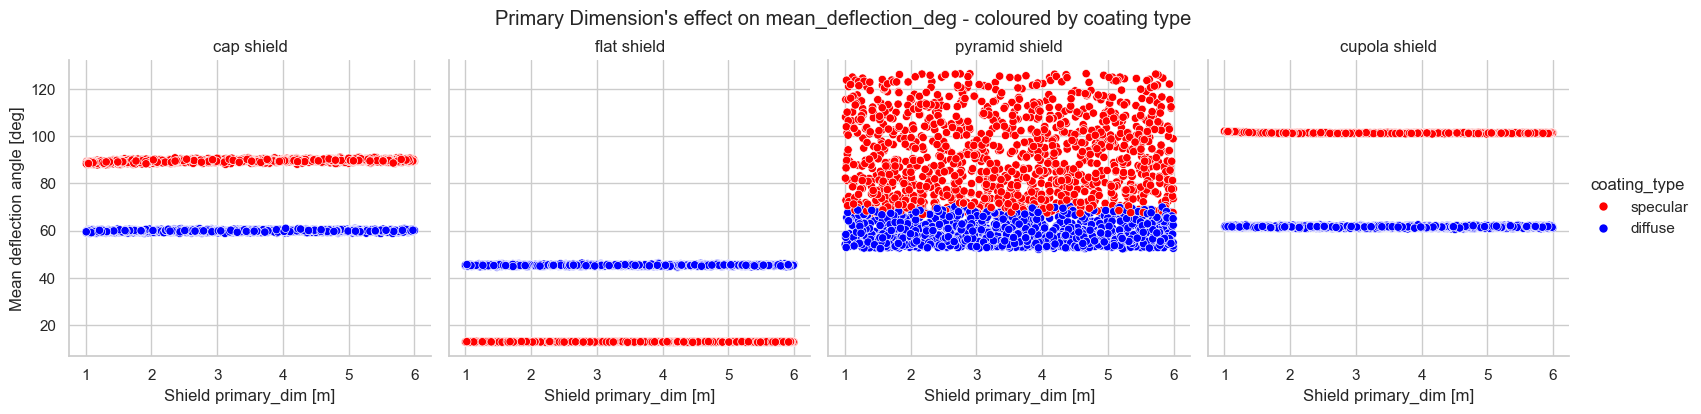

In [ ]:
# --- Scatterplots: mean-defflection_deg -----------------------------------------------
custom_palette = {
    "specular": "red",  
    "diffuse": "blue",   
}

# Plot: mean deflection vs primary_dim
g = sns.relplot(
    data=df, x="primary_dim", y="mean_deflection_deg",
    col="profile", hue="coating_type", palette=custom_palette,
    col_order=["cap", "flat", "pyramid", "cupola"],
    height=4, aspect=1
)

g.set_axis_labels("Shield primary_dim [m]", "Mean deflection angle [deg]")
g.set_titles(col_template="{col_name} shield")
g.fig.suptitle("Primary Dimension's effect on mean_deflection_deg - coloured by coating type", y=1.03)
plt.show()

,_combo,d_mean_deflection_deg,d_hit_ratio,d_wake_intrusion,wafer_flux_ratio
0,pyramid:diffuse,45.346317,0.000000,-0.073180,NaN
1,pyramid:specular,76.838447,0.000000,0.000120,NaN
2,flat:diffuse,32.532055,0.000000,0.000205,NaN
3,cap:specular,41.476258,0.000000,0.001850,NaN
4,cap:diffuse,37.772471,0.000000,0.036120,NaN
5,cupola:specular,88.486552,0.003845,0.650730,NaN
6,cupola:diffuse,48.691009,0.004115,-0.107505,NaN


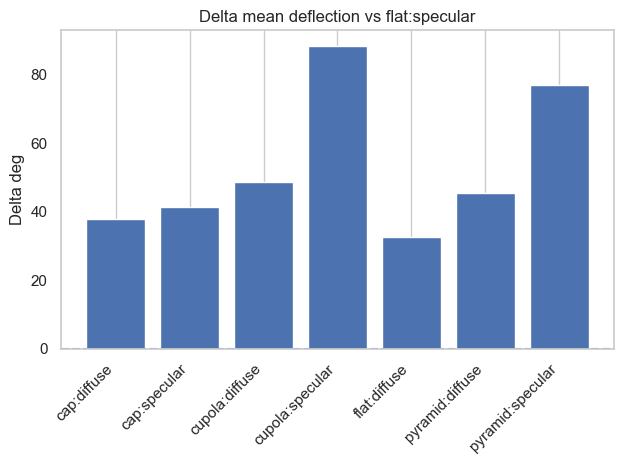

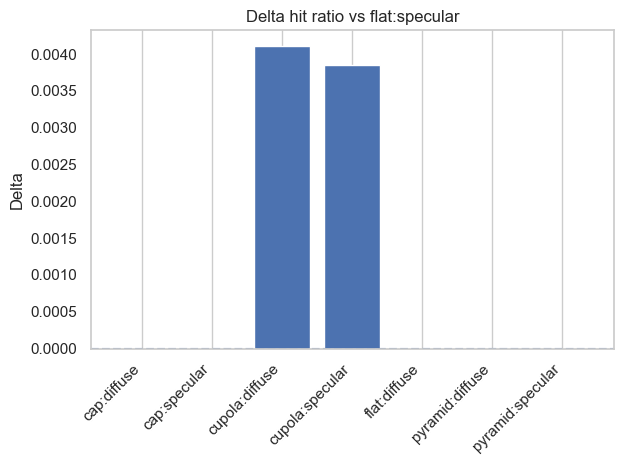

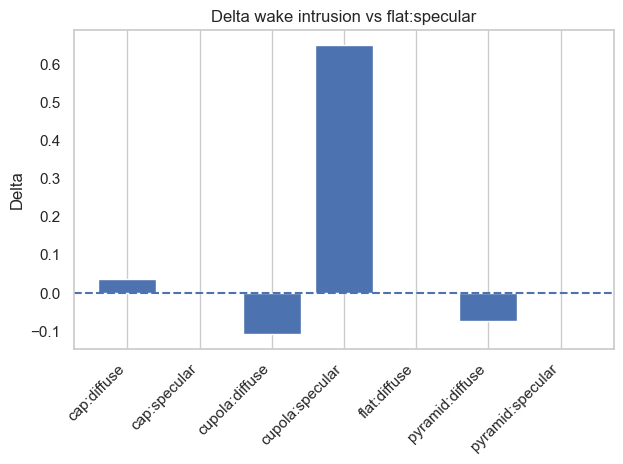

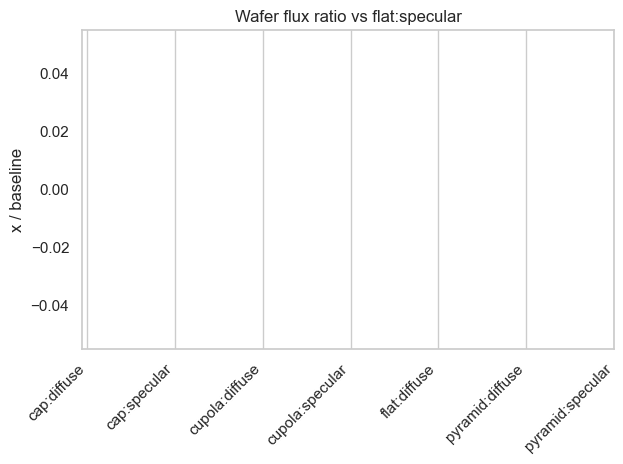

In [ ]:
# === Flat (specular) vs the other 7 shield/coating combos — graphs (robust) ===
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path

# 0) Get a DataFrame: prefer existing `df`; otherwise read CSV_PATH
if "df" in globals() and isinstance(df, pd.DataFrame):
    source_df = df.copy()
else:
    assert "CSV_PATH" in globals(), "Define CSV_PATH or ensure `df` exists."
    source_df = pd.read_csv(CSV_PATH)

# 1) Normalize column names (trim, lower, spaces -> underscores)
source_df.columns = (
    source_df.columns.astype(str).str.strip().str.replace(r"\s+", "_", regex=True).str.lower()
)

# 2) Resolve column names flexibly
def choose(colnames, *opts, required=True):
    for c in opts:
        if c in colnames:
            return c
    if required:
        raise KeyError(f"Missing any of: {opts}. Available: {sorted(colnames)}")
    return None

cols = set(source_df.columns)

profile_col = choose(cols, "profile", "shape", "shield_profile", "geometry")
coating_col = choose(cols, "coating", "coating_type", "surface", "scatter_model")
defl_col    = choose(cols, "mean_deflection_deg", "mean_deflection_dev_deg", "mean_deflection_dev",
                     "mean_deflection", "deflection_deg", "mean_defl_deg")
hit_col     = choose(cols, "hit_ratio", "wafer_hit_ratio", "hits_ratio")
intr_col    = choose(cols, "wake_intrusion", "wake_intrusion_ratio")
flux_col    = choose(cols, "wafer_flux_m2s", "wafer_flux", "flux_wafer")
# primary is optional; fallback mode if absent
primary_col = choose(cols, "primary_dim", "primary", "shield_radius", "radius", "r_shield", required=False)

# 3) Clean up values we filter on
dfc = source_df.copy()
dfc[profile_col] = dfc[profile_col].astype(str).str.lower().str.strip()
dfc[coating_col] = dfc[coating_col].astype(str).str.lower().str.strip()

# Define baseline (flat + specular)
base_mask = dfc[profile_col].isin(["flat", "disk"]) & dfc[coating_col].isin(["specular", "spec"])
baseline_df = dfc[base_mask]
if baseline_df.empty:
    raise ValueError("Baseline (flat + specular) not found. Check `profile` and `coating` values.")

# 4) Branch: with or without primary_dim
if primary_col and primary_col in dfc.columns:
    # ---- A) Curves vs primary_dim ----
    base_g = (baseline_df
              .groupby(primary_col, as_index=True)[[defl_col, hit_col, intr_col, flux_col]]
              .mean().sort_index())

    others = dfc[~base_mask].copy()
    others["_combo"] = others[profile_col] + ":" + others[coating_col]

    curves = {}
    for combo, g in others.groupby("_combo"):
        g2 = g.groupby(primary_col, as_index=True)[[defl_col, hit_col, intr_col, flux_col]].mean().sort_index()
        aligned = g2.join(base_g, how="inner", lsuffix="_x", rsuffix="_base")
        if aligned.empty:
            continue
        out = pd.DataFrame(index=aligned.index)
        out["d_mean_deflection_deg"] = aligned[f"{defl_col}_x"] - aligned[f"{defl_col}_base"]
        out["d_hit_ratio"]           = aligned[f"{hit_col}_x"]  - aligned[f"{hit_col}_base"]
        out["d_wake_intrusion"]      = aligned[f"{intr_col}_x"] - aligned[f"{intr_col}_base"]
        base_flux = aligned[f"{flux_col}_base"].replace(0, np.nan)
        out["wafer_flux_ratio"]      = aligned[f"{flux_col}_x"] / base_flux
        curves[combo] = out

    if not curves:
        raise ValueError("No overlapping primary_dim values between baseline and other combos.")

    def plot_metric(metric_key, y_label, zero_line=True):
        plt.figure()
        for combo, dfm in sorted(curves.items()):
            if metric_key in dfm.columns:
                plt.plot(dfm.index.values, dfm[metric_key].values, marker="o", linewidth=1.5, label=combo)
        if zero_line:
            xs = np.array(sorted(set().union(*[dfm.index.values.tolist() for dfm in curves.values()])))
            if xs.size > 0:
                plt.plot(xs, np.zeros_like(xs), linestyle="--", linewidth=1)
        plt.xlabel(primary_col)
        plt.ylabel(y_label)
        plt.title(f"Difference vs baseline (flat:specular) — {y_label}")
        plt.legend()
        plt.grid(True)

    plot_metric("d_mean_deflection_deg", "Delta mean deflection (deg)")
    plot_metric("d_hit_ratio", "Delta hit ratio")
    plot_metric("d_wake_intrusion", "Delta wake intrusion")
    plot_metric("wafer_flux_ratio", "Wafer flux ratio (x / baseline)", zero_line=False)

    # Summary table averaged across shared primary_dim
    summary = (
        pd.concat(curves, names=["combo", primary_col])
          .reset_index(level=0)
          .groupby("combo", as_index=False)[
              ["d_mean_deflection_deg","d_hit_ratio","d_wake_intrusion","wafer_flux_ratio"]
          ].mean()
          .sort_values(by=["d_hit_ratio","d_wake_intrusion","wafer_flux_ratio","d_mean_deflection_deg"])
          .reset_index(drop=True)
    )
    display(summary)

else:
    # ---- B) No primary_dim: aggregate and show bar charts ----
    base_row = baseline_df[[defl_col, hit_col, intr_col, flux_col]].mean()

    others = dfc[~base_mask].copy()
    others["_combo"] = others[profile_col] + ":" + others[coating_col]
    agg = (others.groupby("_combo", as_index=True)[[defl_col, hit_col, intr_col, flux_col]]
                 .mean()
                 .sort_index())

    comp = pd.DataFrame(index=agg.index)
    comp["d_mean_deflection_deg"] = agg[defl_col] - base_row[defl_col]
    comp["d_hit_ratio"]           = agg[hit_col]  - base_row[hit_col]
    comp["d_wake_intrusion"]      = agg[intr_col] - base_row[intr_col]
    comp["wafer_flux_ratio"]      = agg[flux_col] / (base_row[flux_col] if base_row[flux_col] != 0 else np.nan)

    # Bar plots (no seaborn)
    def bar_plot(series, title, ylabel, zero_line=True):
        plt.figure()
        x = np.arange(len(series))
        plt.bar(x, series.values)
        plt.xticks(x, series.index, rotation=45, ha="right")
        if zero_line:
            plt.axhline(0.0, linestyle="--")
        plt.title(title)
        plt.ylabel(ylabel)
        plt.tight_layout()
        plt.grid(axis="y")

    bar_plot(comp["d_mean_deflection_deg"], "Delta mean deflection vs flat:specular", "Delta deg")
    bar_plot(comp["d_hit_ratio"],           "Delta hit ratio vs flat:specular",      "Delta")
    bar_plot(comp["d_wake_intrusion"],      "Delta wake intrusion vs flat:specular", "Delta")
    bar_plot(comp["wafer_flux_ratio"],      "Wafer flux ratio vs flat:specular",     "x / baseline", zero_line=False)

    # Summary table
    comp_sorted = comp.sort_values(by=["d_hit_ratio","d_wake_intrusion","wafer_flux_ratio","d_mean_deflection_deg"])
    display(comp_sorted.reset_index().rename(columns={"index":"combo"}))


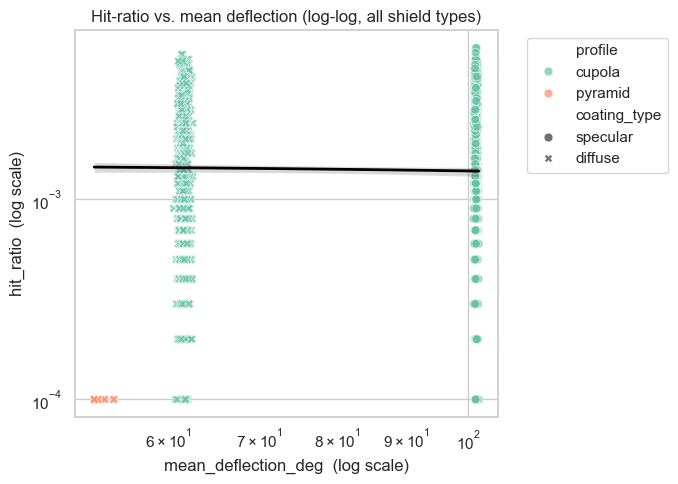

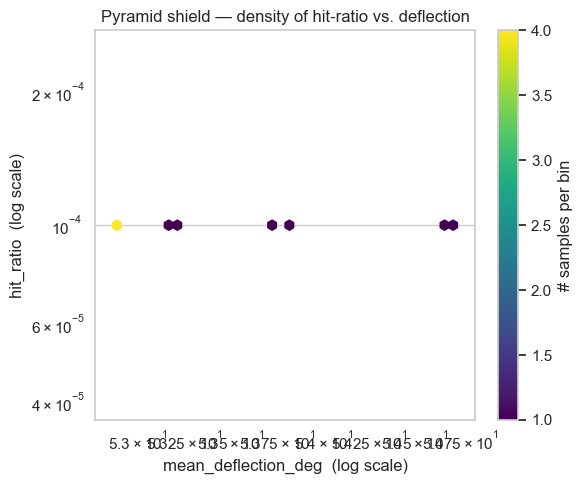

In [ ]:
# ------------------------------------------------------------------
#  A. Global log–log scatter (all shields together)
# ------------------------------------------------------------------
df_plot = df[(df["mean_deflection_deg"] > 0) & (df["hit_ratio"] > 0)]

plt.figure(figsize=(7,5))
sns.scatterplot(data=df_plot,
                x="mean_deflection_deg", y="hit_ratio",
                hue="profile", style="coating_type",
                palette="Set2", s=40, alpha=0.7)

# add one robust global trend line (black)
sns.regplot(data=df_plot, x="mean_deflection_deg", y="hit_ratio",
            scatter=False, robust=True, color="black",
            line_kws={"lw":2, "label":"overall trend"})

plt.xscale("log")
plt.yscale("log")
plt.xlabel("mean_deflection_deg  (log scale)")
plt.ylabel("hit_ratio  (log scale)")
plt.title("Hit-ratio vs. mean deflection (log-log, all shield types)")
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------------
#  B.  Pyramid shield only – hex-bin density plot
# ------------------------------------------------------------------
pyr = df[(df["profile"]=="pyramid") & (df["mean_deflection_deg"] > 0)]

pyr_nz = pyr[(pyr["mean_deflection_deg"] > 0) & (pyr["hit_ratio"] > 0)]

plt.figure(figsize=(6, 5))
hb = plt.hexbin(
        pyr_nz["mean_deflection_deg"],
        pyr_nz["hit_ratio"],
        gridsize=40, mincnt=1, cmap="viridis",
        xscale="log", yscale="log"
)
plt.colorbar(hb, label="# samples per bin")

plt.xlabel("mean_deflection_deg  (log scale)")
plt.ylabel("hit_ratio  (log scale)")
plt.title("Pyramid shield — density of hit-ratio vs. deflection")
plt.tight_layout()
plt.show()

In [ ]:
RANK_COLS = ["hit_ratio","wake_intrusion_ratio","mean_deflection_deg","wafer_flux_m2s"]

# 0) Clean dtypes
for c in RANK_COLS:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# 1) prioritize diffuse coating due to lowest wake intrusion ratio across all shield profiles
cand = df.query("profile in ['cap','flat','pyramid','cupola'] and coating_type == 'diffuse'").copy()

# 2) treat missing values as worst for minimization (and worst for max metric when negated)
cand["hit_ratio"]            = cand["hit_ratio"].fillna(np.inf)
cand["wake_intrusion_ratio"] = cand["wake_intrusion_ratio"].fillna(np.inf)
cand["wafer_flux_m2s"]       = cand["wafer_flux_m2s"].fillna(np.inf)
cand["mean_deflection_deg"]  = cand["mean_deflection_deg"].fillna(-np.inf)

# 3) Hard constraints 
EPS = 1e-6
cand = cand[
    (cand["hit_ratio"] <= 1e-4) &                 # essentially zero hits at wafer
    (cand["wake_intrusion_ratio"] <= 0.20)        # <= 30% wake intrusion
]

# 4) Normalize so metrics are on comparable scales
def minmax(s):
    s = s.astype(float)
    return (s - s.min()) / (s.max() - s.min() + 1e-12)

cand["n_hit"]   = minmax(cand["hit_ratio"])                 # lower is better
cand["n_intr"]  = minmax(cand["wake_intrusion_ratio"])      # lower is better
cand["n_flux"]  = minmax(cand["wafer_flux_m2s"])            # lower is better
cand["n_defl"]  = 1 - minmax(cand["mean_deflection_deg"])   # higher deflection -> lower penalty

# 5) Weighted composite (weights reflect priorities)
w_hit, w_intr, w_flux, w_defl = 0.45, 0.45, 0.05, 0.05
cand["score"] = (w_hit*cand["n_hit"] +
                 w_intr*cand["n_intr"] +
                 w_flux*cand["n_flux"] +
                 w_defl*cand["n_defl"])

best = cand.sort_values("score", ascending=True).iloc[0]
print(f"\n------------------------The Top Performing Shields------------------------\n {cand.sort_values("score", ascending=True).head(5)}\n")
best_per_profile = cand.sort_values("score").groupby("profile").first()
print(f"------------------------The best is------------------------ \n{best} \n ------------------------Best Profiles (<30% Wake Intrusion Ratio):------------------------ \n{best_per_profile}")


------------------------The Top Performing Shields------------------------
      profile  primary_dim  shape_param  thickness coating_type  z_offset  \
1107  cupola     1.018351          1.0   0.002679      diffuse -1.498478   
1015  cupola     1.023689          1.0   0.002855      diffuse -1.379435   
8040  cupola     1.054687          1.0   0.002698      diffuse -1.493372   
2838  cupola     1.091609          1.0   0.001574      diffuse -1.484331   
1783  cupola     1.095821          1.0   0.002544      diffuse -1.357870   

      xy_offset_x  xy_offset_y        mass  mean_deflection_deg  hit_ratio  \
1107    -0.032134     0.024488  111.476816            62.135708        0.0   
1015    -0.013537     0.018960  120.036994            61.748016        0.0   
8040    -0.034644    -0.040597  120.390035            61.382668        0.0   
2838    -0.028113    -0.013247   75.253727            61.453816        0.0   
1783     0.012919    -0.047985  122.546163            61.982232        0.0  